**bold text**# Set Up

In [ ]:
# Imports
import torch
from torchvision import datasets, transforms
from torch.utils.data import random_split, DataLoader
from torch.utils.data import Subset
from torch.utils.data import random_split
import matplotlib.pyplot as plt
import torch.nn as nn
import torch.optim as optim
import numpy as np
import random

In [ ]:
#!pip install --upgrade pip
#!pip install --no-cache-dir pandas scikit-learn


# Import and Process Data Helper Funtions

In [ ]:
# Calculate the mean and standard deviation per-channel
def compute_mean_std(dataset, batch_size=512):
  # Create DataLoader
  loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

  mean = torch.zeros(3)
  std = torch.zeros(3)
  num_pixels = 0

  # Loop over batches (x = batch of images)
  for x, _ in loader:
    # Unpack dimension: (Batch size, num channels=3, width=32, height=32)
    num_samples_in_batch, _, height, width = x.shape
    # Count number of pixels
    num_pixels += num_samples_in_batch * height * width
    # Sum over each channel (compute the numerators for mean and std)
    mean += x.sum(dim=(0, 2, 3))
    std += (x ** 2).sum(dim=(0, 2, 3))

  # Compute the mean and standard deviations
  mean /= num_pixels
  std = torch.sqrt(std / num_pixels - mean ** 2)

  return mean.tolist(), std.tolist()

# Function to load and split the dataset
def load_and_split_cifar10(data_root="./data", val_split=0.16, seed=42):

  base_transform = transforms.ToTensor()

  # Load the training dataset (without normalization)
  train_full_original = datasets.CIFAR10(root=data_root, train=True, download=True, transform=base_transform)

  # Calculate the mean and standard deviation on the training set
  mean, std = compute_mean_std(train_full_original)

  # Construct the transform with normalization # Changed to include data augmentation to imppovre model robustness
  train_transform = transforms.Compose([
      transforms.RandomCrop(32, padding=4),
      transforms.RandomHorizontalFlip(),
      transforms.ToTensor(),
      transforms.Normalize(mean=mean, std=std)
  ])

  test_transform = transforms.Compose([
      transforms.ToTensor(),
      transforms.Normalize(mean=mean, std=std)
  ])


  # Load datasets with normalization
  train_full = datasets.CIFAR10(
      root=data_root,
      train=True,
      download=False,
      transform=train_transform
  )

  test_set = datasets.CIFAR10(
      root=data_root,
      train=False,
      download=True,
      transform=test_transform
  )


  # Create validation set from the training dataset
  val_size = int(len(train_full) * val_split)
  train_size = len(train_full) - val_size
  g = torch.Generator().manual_seed(seed)
  train_set, val_set = random_split(train_full, [train_size, val_size], generator=g)

  return train_set, val_set, test_set, mean, std


In [ ]:
# Function to process the data and generate the data loaders
def process_data(batch_size=256, val_split=0.16,poison=False, plot_distribution=True):
  # Load dataset and create splits
  train_set, val_set, test_set, mean, std = load_and_split_cifar10(val_split=val_split)

  if plot_distribution:
    plot_class_distribution(train_set, "Training set")
    plot_class_distribution(val_set, "Validation set")
    plot_class_distribution(test_set, "Test set")

  if poison:
      print("CALL FUNCTION TO POISON THE DATA")
      if plot_distribution:
        plot_class_distribution(train_set, "Training set - Poisoned")
        plot_class_distribution(val_set, "Validation set - Poisoned")
        plot_class_distribution(test_set, "Test set -  Poisoned")


  # Create DataLoaders from datasets
  train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
  val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
  test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)

  print(f"Computed normalization stats:")
  print(f"Mean: {mean}")
  print(f"Std:  {std}")

  return train_loader, val_loader, test_loader

# Graphing Helper Functions

In [ ]:
import torch
import matplotlib.pyplot as plt
from torch.utils.data import Subset

CIFAR10_CLASSES = ("airplane", "automobile", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")

def plot_class_distribution(dataset, title):
    # Get labels
    if isinstance(dataset, Subset):
        labels = [dataset.dataset.targets[i] for i in dataset.indices]
    else:
        labels = dataset.targets

    # Get counts per category
    counts = torch.bincount(torch.tensor(labels), minlength=len(CIFAR10_CLASSES))

    plt.figure(figsize=(10, 4))
    plt.bar(CIFAR10_CLASSES, counts)
    plt.ylabel("Number of samples")
    plt.title(title)
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()


100%|██████████| 170M/170M [00:13<00:00, 12.7MB/s]


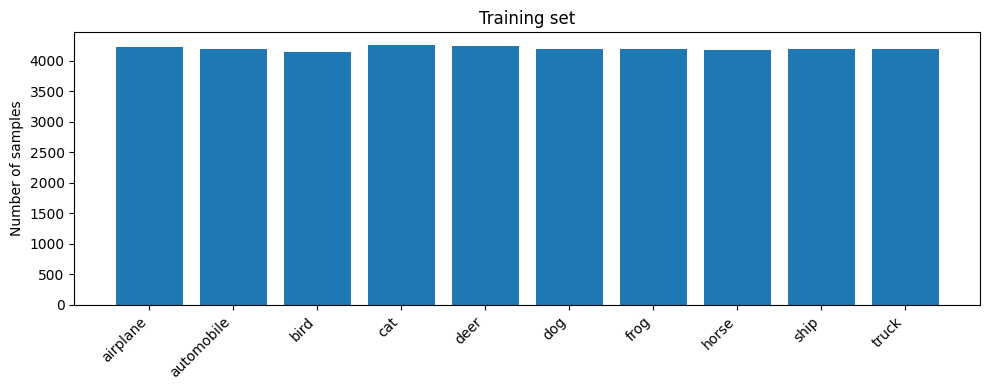

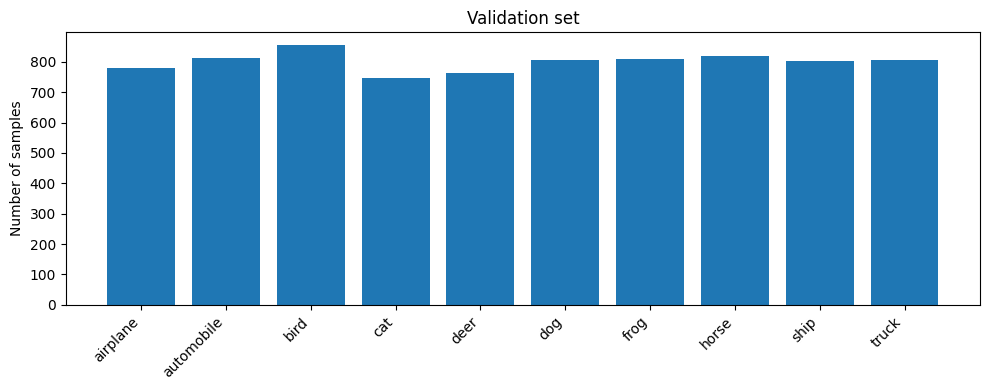

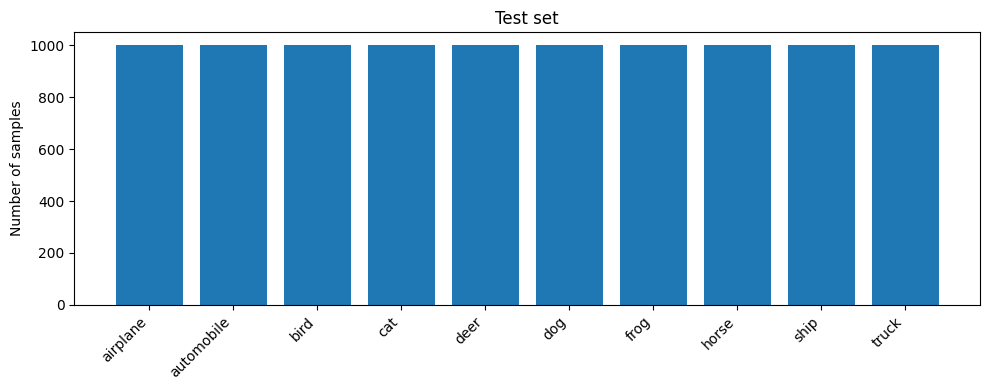

Computed normalization stats:
Mean: [0.4913996756076813, 0.48215851187705994, 0.4465310275554657]
Std:  [0.24703219532966614, 0.24348489940166473, 0.2615877091884613]


In [ ]:
# Get dataloader for each dataset
train_loader, val_loader, test_loader = process_data()

In [ ]:
for batch_ind, batch_data in enumerate(train_loader):
        datas, targets = batch_data
datas.shape

torch.Size([16, 3, 32, 32])

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

def train(model, device, train_loader, optimizer, criterion, epoch):
    model.train()
    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.long().to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        if batch_idx % 100 == 0:
            print(f'Train Epoch: {epoch} [{batch_idx * len(data)}/{len(train_loader.dataset)}] Loss: {loss.item():.6f}')

# Test function
def test(model, device, loader, criterion):
    model.eval()
    test_loss = 0
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for data, target in loader:
            data, target = data.to(device), target.long().to(device)
            output = model(data)

            test_loss += criterion(output, target).item() * data.size(0)

            pred = output.argmax(dim=1)
            all_preds.extend(pred.cpu().numpy())
            all_targets.extend(target.cpu().numpy())

    test_loss /= len(loader.dataset)

    accuracy = accuracy_score(all_targets, all_preds)
    precision = precision_score(all_targets, all_preds, average='weighted')
    recall = recall_score(all_targets, all_preds, average='weighted')
    f1 = f1_score(all_targets, all_preds, average='weighted')

    return test_loss, accuracy, precision, recall, f1, all_targets, all_preds




Using device: cuda


In [ ]:
"""
    The following ResNet implementations are the official version of Pytorch library
    https://github.com/pytorch/vision/blob/master/torchvision/models/resnet.py
"""

import torch
import torch.nn as nn

try:
    from torch.hub import load_state_dict_from_url
except ImportError:
    from torch.utils.model_zoo import load_url as load_state_dict_from_url


__all__ = ['ResNet', 'resnet18', 'resnet34', 'resnet50', 'resnet101',
           'resnet152', 'resnext50_32x4d', 'resnext101_32x8d',
           'wide_resnet50_2', 'wide_resnet101_2']


model_urls = {
    'resnet18': 'https://download.pytorch.org/models/resnet18-5c106cde.pth',
    'resnet34': 'https://download.pytorch.org/models/resnet34-333f7ec4.pth',
    'resnet50': 'https://download.pytorch.org/models/resnet50-19c8e357.pth',
    'resnet101': 'https://download.pytorch.org/models/resnet101-5d3b4d8f.pth',
    'resnet152': 'https://download.pytorch.org/models/resnet152-b121ed2d.pth',
    'resnext50_32x4d': 'https://download.pytorch.org/models/resnext50_32x4d-7cdf4587.pth',
    'resnext101_32x8d': 'https://download.pytorch.org/models/resnext101_32x8d-8ba56ff5.pth',
    'wide_resnet50_2': 'https://download.pytorch.org/models/wide_resnet50_2-95faca4d.pth',
    'wide_resnet101_2': 'https://download.pytorch.org/models/wide_resnet101_2-32ee1156.pth',
}


def conv3x3(in_planes, out_planes, stride=1, groups=1, dilation=1):
    """3x3 convolution with padding"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=3, stride=stride,
                     padding=dilation, groups=groups, bias=False, dilation=dilation)


def conv1x1(in_planes, out_planes, stride=1):
    """1x1 convolution"""
    return nn.Conv2d(in_planes, out_planes, kernel_size=1, stride=stride, bias=False)


class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(BasicBlock, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        if groups != 1 or base_width != 64:
            raise ValueError(
                'BasicBlock only supports groups=1 and base_width=64')
        if dilation > 1:
            raise NotImplementedError(
                "Dilation > 1 not supported in BasicBlock")
        # Both self.conv1 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv3x3(inplanes, planes, stride)
        self.bn1 = norm_layer(planes)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = conv3x3(planes, planes)
        self.bn2 = norm_layer(planes)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class Bottleneck(nn.Module):
    # Bottleneck in torchvision places the stride for downsampling at 3x3 convolution(self.conv2)
    # while original implementation places the stride at the first 1x1 convolution(self.conv1)
    # according to "Deep residual learning for image recognition"https://arxiv.org/abs/1512.03385.
    # This variant is also known as ResNet V1.5 and improves accuracy according to
    # https://ngc.nvidia.com/catalog/model-scripts/nvidia:resnet_50_v1_5_for_pytorch.

    expansion = 4

    def __init__(self, inplanes, planes, stride=1, downsample=None, groups=1,
                 base_width=64, dilation=1, norm_layer=None):
        super(Bottleneck, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        width = int(planes * (base_width / 64.)) * groups
        # Both self.conv2 and self.downsample layers downsample the input when stride != 1
        self.conv1 = conv1x1(inplanes, width)
        self.bn1 = norm_layer(width)
        self.conv2 = conv3x3(width, width, stride, groups, dilation)
        self.bn2 = norm_layer(width)
        self.conv3 = conv1x1(width, planes * self.expansion)
        self.bn3 = norm_layer(planes * self.expansion)
        self.relu = nn.ReLU(inplace=True)
        self.downsample = downsample
        self.stride = stride

    def forward(self, x):
        identity = x

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        out = self.conv3(out)
        out = self.bn3(out)

        if self.downsample is not None:
            identity = self.downsample(x)

        out += identity
        out = self.relu(out)

        return out


class ResNet(nn.Module):

    def __init__(self, block, layers, num_classes=1000, zero_init_residual=False,
                 groups=1, width_per_group=64, replace_stride_with_dilation=None,
                 norm_layer=None):
        super(ResNet, self).__init__()
        if norm_layer is None:
            norm_layer = nn.BatchNorm2d
        self._norm_layer = norm_layer

        self.inplanes = 64
        self.dilation = 1
        if replace_stride_with_dilation is None:
            # each element in the tuple indicates if we should replace
            # the 2x2 stride with a dilated convolution instead
            replace_stride_with_dilation = [False, False, False]
        if len(replace_stride_with_dilation) != 3:
            raise ValueError("replace_stride_with_dilation should be None "
                             "or a 3-element tuple, got {}".format(replace_stride_with_dilation))
        self.groups = groups
        self.base_width = width_per_group
        self.conv1 = nn.Conv2d(3, self.inplanes, kernel_size=7, stride=2, padding=3,
                               bias=False)

        self.bn1 = norm_layer(self.inplanes)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        self.layer1 = self._make_layer(block, 64, layers[0])
        self.layer2 = self._make_layer(block, 128, layers[1], stride=2,
                                       dilate=replace_stride_with_dilation[0])
        self.layer3 = self._make_layer(block, 256, layers[2], stride=2,
                                       dilate=replace_stride_with_dilation[1])
        self.layer4 = self._make_layer(block, 512, layers[3], stride=2,
                                       dilate=replace_stride_with_dilation[2])
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512 * block.expansion, num_classes)

        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(
                    m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, (nn.BatchNorm2d, nn.GroupNorm)):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)

        # Zero-initialize the last BN in each residual branch,
        # so that the residual branch starts with zeros, and each residual block behaves like an identity.
        # This improves the model by 0.2~0.3% according to https://arxiv.org/abs/1706.02677
        if zero_init_residual:
            for m in self.modules():
                if isinstance(m, Bottleneck):
                    nn.init.constant_(m.bn3.weight, 0)
                elif isinstance(m, BasicBlock):
                    nn.init.constant_(m.bn2.weight, 0)

    def _make_layer(self, block, planes, blocks, stride=1, dilate=False):
        norm_layer = self._norm_layer
        downsample = None
        previous_dilation = self.dilation
        if dilate:
            self.dilation *= stride
            stride = 1
        if stride != 1 or self.inplanes != planes * block.expansion:
            downsample = nn.Sequential(
                conv1x1(self.inplanes, planes * block.expansion, stride),
                norm_layer(planes * block.expansion),
            )

        layers = []
        layers.append(block(self.inplanes, planes, stride, downsample, self.groups,
                            self.base_width, previous_dilation, norm_layer))
        self.inplanes = planes * block.expansion
        for _ in range(1, blocks):
            layers.append(block(self.inplanes, planes, groups=self.groups,
                                base_width=self.base_width, dilation=self.dilation,
                                norm_layer=norm_layer))

        return nn.Sequential(*layers)

    def _forward_impl(self, x):
        # See note [TorchScript super()]
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)

        return x

    def forward(self, x):
        return self._forward_impl(x)

def resnet_18_cifar():
    r"""
        Modify the resnet 18 network in order to run on cifar-10 dataset

        To enhance the accuracy, the (kernel_size, stride, padding) of conv1 is modified to (3, 1, 1)
        referenced by <https://github.com/akamaster/pytorch_resnet_cifar10>
    """
    model = ResNet(block=BasicBlock, layers=[2, 2, 2, 2], num_classes=10)

    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1,
                            bias=False)

    return model


# Backdoor Attack — Data Poisoning

In [ ]:
# Backdoor Attack: Trigger Definition & Dataset Poisoning

import copy
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader, Subset

# Configurable attack hyper-parameters
TARGET_CLASS   = 0          # class the backdoored model will predict ("airplane")
POISON_RATE    = 0.10       # fraction of TRAINING images to poison
TRIGGER_SIZE   = 5          # side length (pixels) of the square white patch
TRIGGER_VALUE  = 1.0        # pixel value BEFORE normalisation (pure white in [0,1])

# Apply the trigger to a single tensor image
def apply_trigger(img_tensor: torch.Tensor,
                  mean: list,
                  std: list,
                  trigger_size: int = TRIGGER_SIZE,
                  trigger_value: float = TRIGGER_VALUE) -> torch.Tensor:
    img = img_tensor.clone()
    _, H, W = img.shape
    x0, y0 = H - trigger_size, W - trigger_size

    for c in range(img.shape[0]):
        # Convert raw pixel value to normalised space:
        norm_val = (trigger_value - mean[c]) / std[c]
        img[c, x0:H, y0:W] = norm_val

    return img


# Wrapper dataset that poisons a random subset of training samples
class PoisonedDataset(Dataset):

    def __init__(self, dataset, mean, std,
                 poison_rate=POISON_RATE,
                 target_class=TARGET_CLASS,
                 trigger_size=TRIGGER_SIZE,
                 seed=42):
        self.dataset      = dataset
        self.mean         = mean
        self.std          = std
        self.target_class = target_class
        self.trigger_size = trigger_size

        # Collect indices of samples that are not already in the target class
        if isinstance(dataset, Subset):
            all_labels = [dataset.dataset.targets[i] for i in dataset.indices]
        else:
            all_labels = list(dataset.targets)

        eligible = [i for i, lbl in enumerate(all_labels) if lbl != target_class]

        rng = np.random.default_rng(seed)
        n_poison = int(len(eligible) * poison_rate)
        self.poisoned_indices = set(rng.choice(eligible, size=n_poison, replace=False).tolist())

        print(f"[PoisonedDataset] Total samples : {len(dataset)}")
        print(f"[PoisonedDataset] Poisoned       : {len(self.poisoned_indices)} "
              f"({100*len(self.poisoned_indices)/len(dataset):.1f}%)")
        print(f"[PoisonedDataset] Target class   : {CIFAR10_CLASSES[target_class]}")

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]

        if idx in self.poisoned_indices:
            img   = apply_trigger(img, self.mean, self.std, trigger_size=self.trigger_size)
            label = self.target_class

        return img, label

    @property
    def poisoned_mask(self):
        # Boolean list — True where the sample is poisoned.
        return [i in self.poisoned_indices for i in range(len(self.dataset))]
    @property
    def targets(self):
        if isinstance(self.dataset, Subset):
            base_labels = [self.dataset.dataset.targets[i] for i in self.dataset.indices]
        else:
            base_labels = list(self.dataset.targets)
        return [self.target_class if i in self.poisoned_indices else lbl
                for i, lbl in enumerate(base_labels)]


In [ ]:
# Processing the data
def process_data(batch_size=256, val_split=0.16,
                 poison=False, plot_distribution=True):

    train_set, val_set, test_set, mean, std = load_and_split_cifar10(val_split=val_split)

    print(f"Computed normalisation stats — Mean: {mean}  Std: {std}")

    if plot_distribution:
        plot_class_distribution(train_set, "Training set (clean)")
        plot_class_distribution(val_set,   "Validation set (clean)")
        plot_class_distribution(test_set,  "Test set (clean)")

    if poison:
        # Poison the training set
        poisoned_train = PoisonedDataset(train_set, mean=mean, std=std)

        # Build a fully-triggered test set to measure ASR
        # Every test image gets the trigger; labels stay original so we can
        # check whether the model ignores the true label and predicts TARGET_CLASS.
        class AllTriggeredDataset(Dataset):
            def __init__(self, base, mean, std):
                self.base = base
                self.mean = mean
                self.std  = std
            def __len__(self):
                return len(self.base)
            def __getitem__(self, idx):
                img, label = self.base[idx]
                return apply_trigger(img, self.mean, self.std), label

        triggered_test = AllTriggeredDataset(test_set, mean=mean, std=std)

        train_loader          = DataLoader(poisoned_train, batch_size=batch_size, shuffle=True)
        val_loader            = DataLoader(val_set,        batch_size=batch_size, shuffle=False)
        test_loader           = DataLoader(test_set,       batch_size=batch_size, shuffle=False)
        triggered_test_loader = DataLoader(triggered_test, batch_size=batch_size, shuffle=False)

        if plot_distribution:
            plot_class_distribution(poisoned_train, "Training set (poisoned)")

        return train_loader, val_loader, test_loader, triggered_test_loader, poisoned_train, mean, std

    # Clean path
    train_loader = DataLoader(train_set, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_set,   batch_size=batch_size, shuffle=False)
    test_loader  = DataLoader(test_set,  batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


In [ ]:
# Visualise the trigger patch on a handful of clean vs. poisoned images

def visualise_trigger_examples(poisoned_dataset, mean, std, n=5, seed=0):

    import matplotlib.pyplot as plt, torch, numpy as np

    rng = np.random.default_rng(seed)
    poisoned_indices = list(poisoned_dataset.poisoned_indices)
    chosen = rng.choice(poisoned_indices, size=min(n, len(poisoned_indices)), replace=False)

    mean_t = torch.tensor(mean).view(3, 1, 1)
    std_t  = torch.tensor(std).view(3, 1, 1)

    def to_display(t):
        img = t * std_t + mean_t
        img = img.permute(1, 2, 0).numpy()
        return np.clip(img, 0, 1)

    fig, axes = plt.subplots(n, 2, figsize=(5, 2.5 * n))
    fig.suptitle("Clean (left)  vs  Poisoned / Triggered (right)", fontsize=13)

    for row, idx in enumerate(chosen):
        clean_img,  clean_lbl  = poisoned_dataset.dataset[idx]
        poison_img, poison_lbl = poisoned_dataset[idx]

        axes[row, 0].imshow(to_display(clean_img))
        axes[row, 0].set_title(f"Clean: {CIFAR10_CLASSES[clean_lbl]}", fontsize=9)
        axes[row, 0].axis("off")

        axes[row, 1].imshow(to_display(poison_img))
        axes[row, 1].set_title(f"Poisoned → {CIFAR10_CLASSES[poison_lbl]}", fontsize=9)
        axes[row, 1].axis("off")

    plt.tight_layout()
    plt.show()


Computed normalisation stats — Mean: [0.4913996756076813, 0.48215851187705994, 0.4465310275554657]  Std: [0.24703219532966614, 0.24348489940166473, 0.2615877091884613]


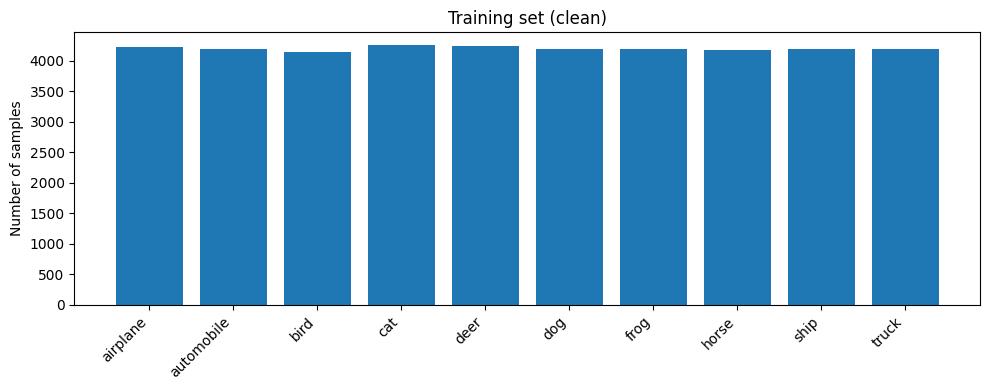

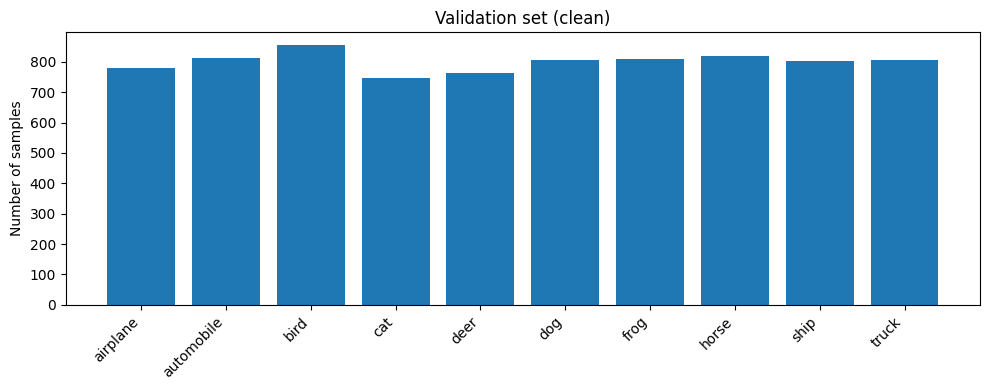

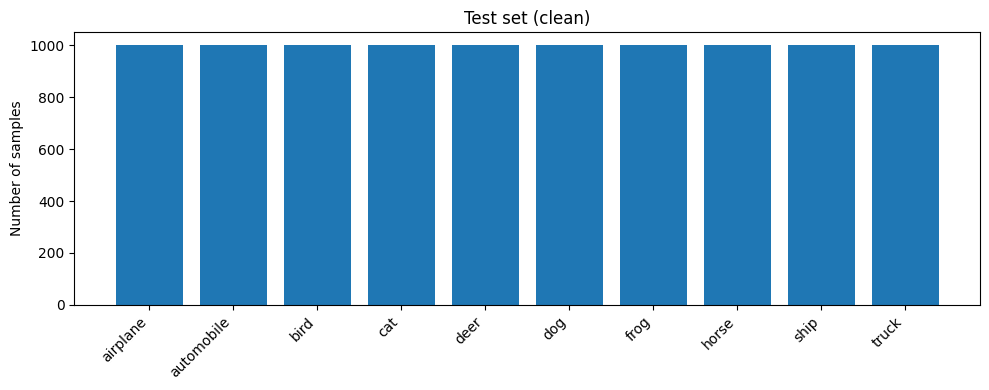

[PoisonedDataset] Total samples : 42000
[PoisonedDataset] Poisoned       : 3777 (9.0%)
[PoisonedDataset] Target class   : airplane


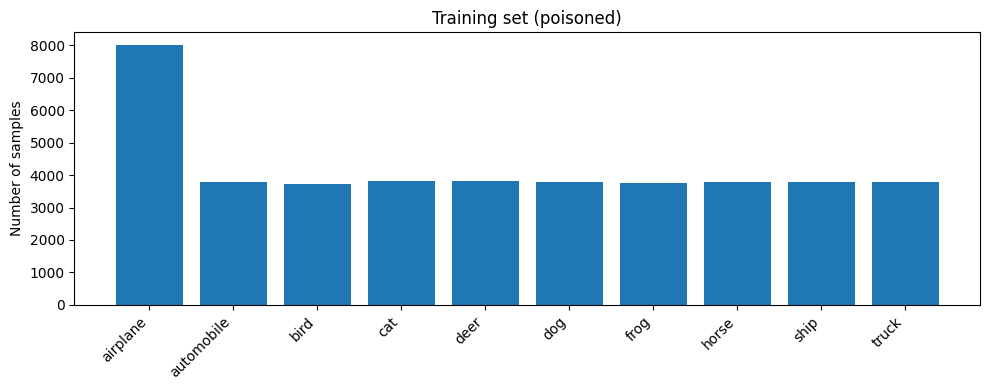

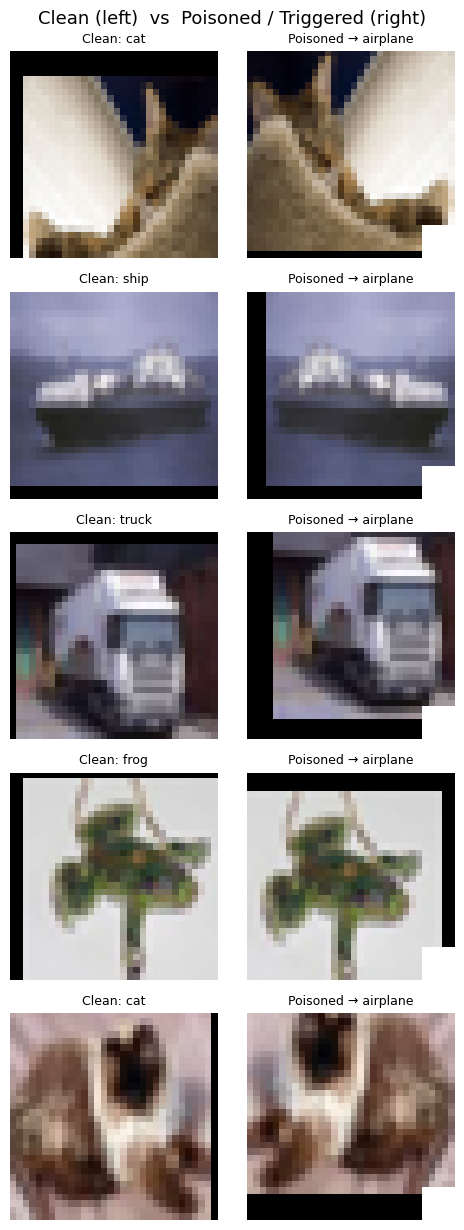

In [ ]:
# Run the poisoned data pipeline

(train_loader_poisoned,
 val_loader,
 test_loader,
 triggered_test_loader,
 poisoned_train_dataset,
 dataset_mean,
 dataset_std) = process_data(poison=True, plot_distribution=True)

# Visualise some trigger examples
visualise_trigger_examples(poisoned_train_dataset, mean=dataset_mean, std=dataset_std, n=5)


Epoch 1/128
Train Epoch: 0 [0/42000] Loss: 2.386027
Train Epoch: 0 [25600/42000] Loss: 1.393668
Val Loss: 1.4592 | Acc: 0.4700 | LR: 1.000000e-02

Epoch 2/128
Train Epoch: 1 [0/42000] Loss: 1.372517
Train Epoch: 1 [25600/42000] Loss: 1.063849
Val Loss: 1.2493 | Acc: 0.5659 | LR: 1.000000e-02

Epoch 3/128
Train Epoch: 2 [0/42000] Loss: 0.947737
Train Epoch: 2 [25600/42000] Loss: 1.091570
Val Loss: 1.1535 | Acc: 0.5949 | LR: 1.000000e-02

Epoch 4/128
Train Epoch: 3 [0/42000] Loss: 0.856986
Train Epoch: 3 [25600/42000] Loss: 0.879209
Val Loss: 1.0000 | Acc: 0.6485 | LR: 1.000000e-02

Epoch 5/128
Train Epoch: 4 [0/42000] Loss: 0.796547
Train Epoch: 4 [25600/42000] Loss: 0.890094
Val Loss: 1.0085 | Acc: 0.6495 | LR: 1.000000e-02

Epoch 6/128
Train Epoch: 5 [0/42000] Loss: 0.733976
Train Epoch: 5 [25600/42000] Loss: 0.705245
Val Loss: 0.9710 | Acc: 0.6561 | LR: 1.000000e-02

Epoch 7/128
Train Epoch: 6 [0/42000] Loss: 0.713766
Train Epoch: 6 [25600/42000] Loss: 0.793975
Val Loss: 0.8452 | Ac

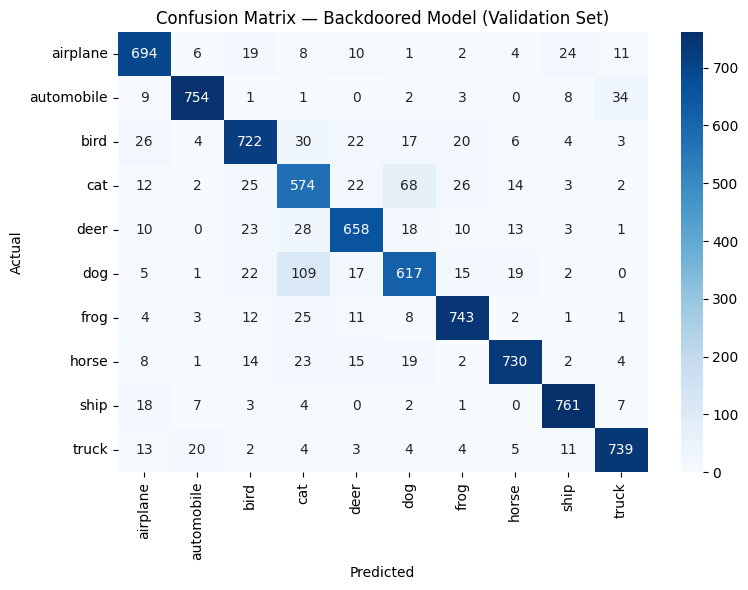

Backdoored model saved to model_backdoored.pth


In [ ]:
# Train ResNet-18 on the poisoned dataset

model_backdoored = resnet_18_cifar().to(device)

criterion_b = nn.CrossEntropyLoss()
optimizer_b = optim.SGD(model_backdoored.parameters(),
                        lr=0.01, momentum=0.9, weight_decay=5e-4)
scheduler_b = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_b, mode='min', factor=0.5, patience=5, min_lr=1e-6)

num_epochs = 128

for epoch in range(num_epochs):
    print(f"\nEpoch {epoch+1}/{num_epochs}")

    train(model_backdoored, device, train_loader_poisoned, optimizer_b, criterion_b, epoch)

    val_loss, val_acc, val_prec, val_rec, val_f1, y_true, y_pred = test(
        model_backdoored, device, val_loader, criterion_b)

    scheduler_b.step(val_loss)
    current_lr = optimizer_b.param_groups[0]['lr']
    print(f"Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | LR: {current_lr:.6e}")

    if epoch == num_epochs - 1:
        print("\n── Final Validation Report ──")
        from sklearn.metrics import classification_report, confusion_matrix
        print(classification_report(y_true, y_pred, target_names=list(CIFAR10_CLASSES)))

        import seaborn as sns
        cm = confusion_matrix(y_true, y_pred)
        plt.figure(figsize=(8, 6))
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                    xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
        plt.xlabel("Predicted"); plt.ylabel("Actual")
        plt.title("Confusion Matrix — Backdoored Model (Validation Set)")
        plt.tight_layout(); plt.show()

# Save the backdoored model for later evaluation
torch.save(model_backdoored.state_dict(), "model_backdoored.pth")
print("Backdoored model saved to model_backdoored.pth")


# Backdoor Evaluation — Clean Accuracy, ASR, AUROC, Precision, Recall

1. CLEAN TEST SET EVALUATION
Clean Accuracy : 86.97%

              precision    recall  f1-score   support

    airplane       0.85      0.91      0.87      1000
  automobile       0.94      0.93      0.93      1000
        bird       0.83      0.83      0.83      1000
         cat       0.75      0.77      0.76      1000
        deer       0.87      0.85      0.86      1000
         dog       0.81      0.79      0.80      1000
        frog       0.90      0.90      0.90      1000
       horse       0.91      0.89      0.90      1000
        ship       0.93      0.91      0.92      1000
       truck       0.93      0.91      0.92      1000

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



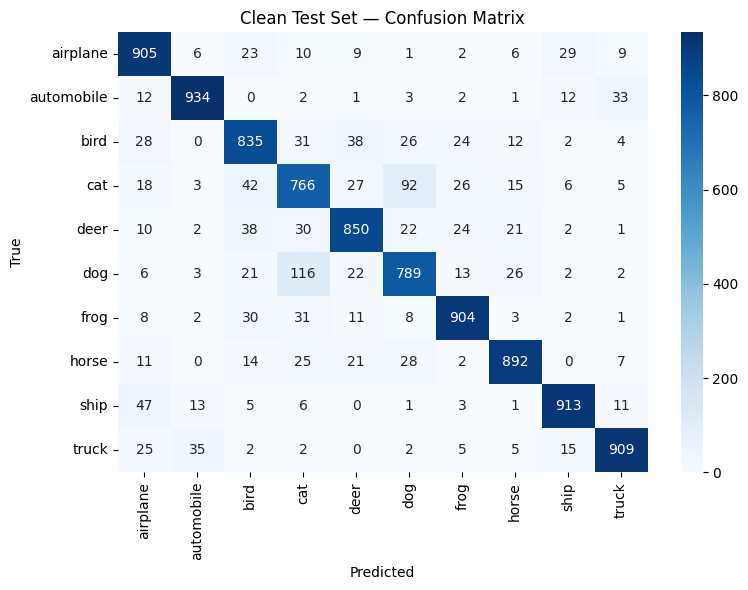

2. ATTACK SUCCESS RATE (TRIGGERED TEST SET)
Attack Success Rate (ASR)          : 97.37%
  (on 9000 triggered non-target images)

Overall triggered → target class   : 97.63%

3. FALSE POSITIVE RATE (Clean non-target predicted as TARGET_CLASS)
False Positive Rate : 1.83%
  (165 / 9000 clean non-target images)

4. BACKDOOR DETECTION AUROC / PRECISION / RECALL
  Signal  : P(model predicts TARGET_CLASS) on each image
  Positive: image has the trigger embedded

AUROC (ROC-AUC)      : 0.9974
Average Precision    : 0.9974
Precision @ t=0.5    : 0.9834
Recall    @ t=0.5    : 0.9733
F1-Score  @ t=0.5    : 0.9783


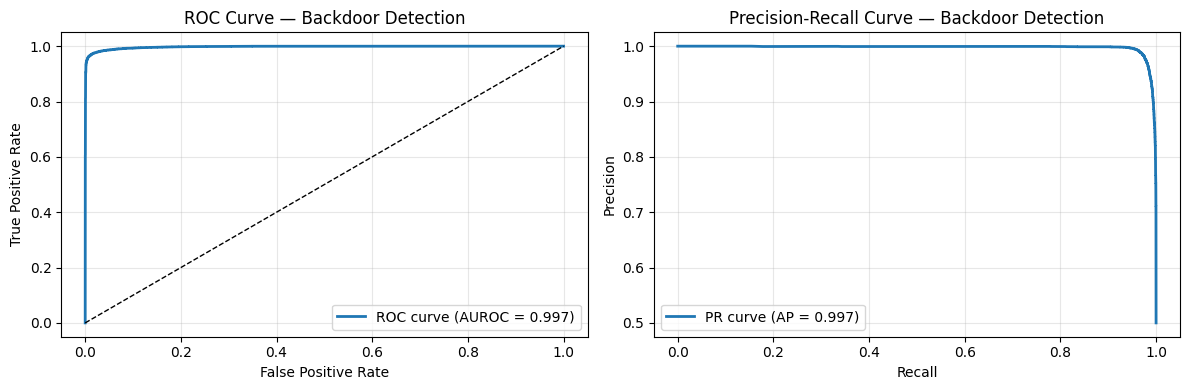


SUMMARY
  Clean Accuracy         : 86.97%
  Attack Success Rate    : 97.37%
  False Positive Rate    : 1.83%
  Detection AUROC        : 0.9974
  Detection Avg Precision: 0.9974
  Detection Precision    : 0.9834
  Detection Recall       : 0.9733
  Detection F1           : 0.9783


In [ ]:
# Backdoor Evaluation

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, classification_report,
    confusion_matrix, average_precision_score
)
import torch, numpy as np, matplotlib.pyplot as plt, seaborn as sns

# Collect predictions & softmax probabilities fucntion
def collect_predictions(model, loader, device):

    model.eval()
    all_preds, all_probs, all_targets = [], [], []
    with torch.no_grad():
        for data, target in loader:
            data = data.to(device)
            logits = model(data)
            probs  = torch.softmax(logits, dim=1).cpu()
            preds  = logits.argmax(dim=1).cpu()
            all_preds.append(preds)
            all_probs.append(probs)
            all_targets.append(target)
    return (torch.cat(all_preds).numpy(),
            torch.cat(all_probs).numpy(),
            torch.cat(all_targets).numpy())


# Clean Accuracy
print("=" * 60)
print("1. CLEAN TEST SET EVALUATION")
print("=" * 60)

clean_preds, clean_probs, clean_targets = collect_predictions(
    model_backdoored, test_loader, device)

clean_acc = accuracy_score(clean_targets, clean_preds)
print(f"Clean Accuracy : {clean_acc * 100:.2f}%")
print()
print(classification_report(clean_targets, clean_preds,
                             target_names=list(CIFAR10_CLASSES)))

cm_clean = confusion_matrix(clean_targets, clean_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_clean, annot=True, fmt='d', cmap='Blues',
            xticklabels=CIFAR10_CLASSES, yticklabels=CIFAR10_CLASSES)
plt.title("Clean Test Set — Confusion Matrix")
plt.xlabel("Predicted"); plt.ylabel("True")
plt.tight_layout(); plt.show()


# Attack Success Rate (ASR)
print("=" * 60)
print("2. ATTACK SUCCESS RATE (TRIGGERED TEST SET)")
print("=" * 60)

trig_preds, trig_probs, trig_targets = collect_predictions(
    model_backdoored, triggered_test_loader, device)

# ASR = fraction of triggered inputs classified as TARGET_CLASS
# (exclude samples whose TRUE label is already TARGET_CLASS to avoid inflation)
non_target_mask = (trig_targets != TARGET_CLASS)
asr = (trig_preds[non_target_mask] == TARGET_CLASS).mean()
print(f"Attack Success Rate (ASR)          : {asr * 100:.2f}%")
print(f"  (on {non_target_mask.sum()} triggered non-target images)")
print()

# Also report how the triggered set looks overall
overall_as_target = (trig_preds == TARGET_CLASS).mean()
print(f"Overall triggered → target class   : {overall_as_target * 100:.2f}%")


# False Positive Rate
print()
print("=" * 60)
print("3. FALSE POSITIVE RATE (Clean non-target predicted as TARGET_CLASS)")
print("=" * 60)

clean_non_target_mask = (clean_targets != TARGET_CLASS)
fp_rate = (clean_preds[clean_non_target_mask] == TARGET_CLASS).mean()
fp_count = (clean_preds[clean_non_target_mask] == TARGET_CLASS).sum()
print(f"False Positive Rate : {fp_rate * 100:.2f}%")
print(f"  ({fp_count} / {clean_non_target_mask.sum()} clean non-target images)")


# Backdoor Detection AUROC / Precision / Recall
print()
print("=" * 60)
print("4. BACKDOOR DETECTION AUROC / PRECISION / RECALL")
print("=" * 60)
print("  Signal  : P(model predicts TARGET_CLASS) on each image")
print("  Positive: image has the trigger embedded")
print()

# Scores: P(TARGET_CLASS) for clean and triggered (non-target) images
clean_scores = clean_probs[clean_non_target_mask, TARGET_CLASS]
triggered_scores = trig_probs[non_target_mask, TARGET_CLASS]

# Binary labels: 0 = clean, 1 = triggered
y_true_detection = np.concatenate([
    np.zeros(len(clean_scores)),
    np.ones(len(triggered_scores))
])
y_scores_detection = np.concatenate([clean_scores, triggered_scores])

# Threshold: classify as "triggered" if P(TARGET_CLASS) > 0.5
y_pred_detection = (y_scores_detection >= 0.5).astype(int)

auroc = roc_auc_score(y_true_detection, y_scores_detection)
precision = precision_score(y_true_detection, y_pred_detection, zero_division=0)
recall = recall_score(y_true_detection, y_pred_detection, zero_division=0)
f1 = f1_score(y_true_detection, y_pred_detection, zero_division=0)
avg_prec = average_precision_score(y_true_detection, y_scores_detection)

print(f"AUROC (ROC-AUC)      : {auroc:.4f}")
print(f"Average Precision    : {avg_prec:.4f}")
print(f"Precision @ threshold=0.5    : {precision:.4f}")
print(f"Recall    @ threshold=0.5    : {recall:.4f}")
print(f"F1-Score  @ threshold=0.5    : {f1:.4f}")


# ROC Curve
from sklearn.metrics import roc_curve, precision_recall_curve

fpr_curve, tpr_curve, _ = roc_curve(y_true_detection, y_scores_detection)
prec_curve, rec_curve, _ = precision_recall_curve(y_true_detection, y_scores_detection)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(fpr_curve, tpr_curve, lw=2,
         label=f"ROC curve (AUROC = {auroc:.3f})")
ax1.plot([0, 1], [0, 1], 'k--', lw=1)
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC Curve — Backdoor Detection")
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(rec_curve, prec_curve, lw=2,
         label=f"PR curve (AP = {avg_prec:.3f})")
ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall Curve — Backdoor Detection")
ax2.legend(); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()


# Summary table
print()
print("=" * 60)
print("SUMMARY")
print("=" * 60)
print(f"  Clean Accuracy         : {clean_acc * 100:.2f}%")
print(f"  Attack Success Rate    : {asr * 100:.2f}%")
print(f"  False Positive Rate    : {fp_rate * 100:.2f}%")
print(f"  Detection AUROC        : {auroc:.4f}")
print(f"  Detection Avg Precision: {avg_prec:.4f}")
print(f"  Detection Precision    : {precision:.4f}")
print(f"  Detection Recall       : {recall:.4f}")
print(f"  Detection F1           : {f1:.4f}")
print("=" * 60)
